# Week 1 Project: Medical Insurance Cost Analysis

This notebook uses the **Medical Cost Personal Dataset** from Kaggle.

Dataset link: https://www.kaggle.com/datasets/mirichoi0218/insurance

For the machine learning part, I use Linear Regression to predict medical insurance charges.


## 1. Import the Dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")


Matplotlib is building the font cache; this may take a moment.


## 2. Inspect the Data


In [2]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Check Missing Values and Duplicates


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows:
1


In [6]:
df = df.drop_duplicates()

## 3. Basic Filtering

Here I filter the dataset to look at people who are older than 50.


In [7]:
older_people = df[df["age"] > 50]

older_people.head()


,age,sex,bmi,children,smoker,region,charges
9,60,female,25.84,0,no,northwest,28923.13692
11,62,female,26.29,0,yes,southeast,27808.72510
13,56,female,39.82,0,no,southeast,11090.71780
16,52,female,30.78,1,no,northeast,10797.33620
18,56,male,40.30,0,no,southwest,10602.38500


I can also filter the data to look only at smokers, since smoking may be related to higher medical costs.


In [8]:
smokers = df[df["smoker"] == "yes"]

smokers.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768


## 4. Grouping and Summary Statistics

I group the data by smoking status and compare the average insurance charges for smokers and non-smokers.


In [9]:
smoker_summary = df.groupby("smoker")["charges"].agg(["mean", "count"])

smoker_summary


,mean,count
smoker,,
no,8440.660307,1063
yes,32050.231832,274


I also group the data by region and calculate the average insurance charge in each region.


In [10]:
region_summary = df.groupby("region")["charges"].mean()

region_summary


region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

## 5. Visualization

The scatter plot below compares BMI with medical insurance charges.

This helps show whether there is a visible relationship between BMI and insurance cost.


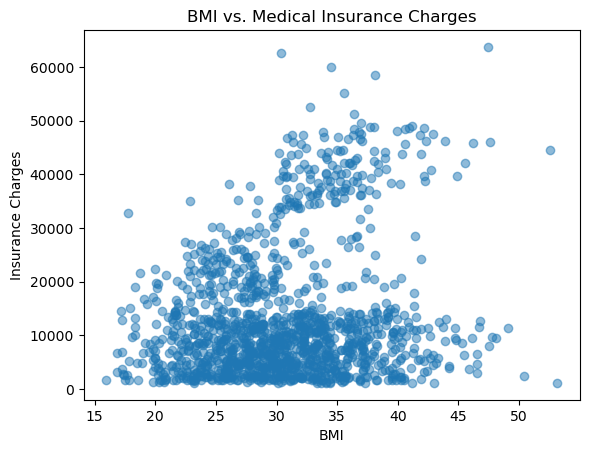

In [11]:
plt.scatter(df["bmi"], df["charges"], alpha=0.5)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs. Medical Insurance Charges")

plt.show()


## 6. Explore a Machine Learning Algorithm

For this project, I chose Linear Regression.

The output variable is `charges`, which is a continuous numerical variable.  
For a simple first model, I use:

- `age`
- `bmi`
- `children`

as the input features.

The goal is to see whether these variables can help predict medical insurance charges. Because the first result is limited, I also build separate Linear Regression models for smokers and non-smokers.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["age", "bmi", "children"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


### Train the Linear Regression Model


In [13]:
model = LinearRegression()

model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Make Predictions


In [14]:
predictions = model.predict(X_test)

print("First 5 predictions:")
print(predictions[:5])


First 5 predictions:
[12217.85512176 11369.7965343  18642.50184425 13600.94185777
 14035.87585693]


### Basic Model Evaluation

I use Mean Squared Error (MSE) and R-squared to get an initial idea of how well the model performs.


In [15]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 158493243.25914004
R-squared: 0.13748020188497823


### Linear Regression by Smoking Status

Because smoking status has a strong relationship with insurance charges, I also fit separate Linear Regression models for smokers and non-smokers.

Each model still uses `age`, `bmi`, and `children` as input features, but the data is split by the `smoker` category first.

In [32]:
# Model for non-smokers
non_smokers = df[df["smoker"] == "no"]

X_no = non_smokers[["age", "bmi", "children"]]
y_no = non_smokers["charges"]

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_no,
    y_no,
    test_size=0.2,
    random_state=42
)

model_no = LinearRegression()
model_no.fit(X_train_no, y_train_no)

predictions_no = model_no.predict(X_test_no)

mse_no = mean_squared_error(y_test_no, predictions_no)
r2_no = r2_score(y_test_no, predictions_no)

print("Non-smokers MSE:", mse_no)
print("Non-smokers R-squared:", r2_no)

Non-smokers MSE: 22457821.8583968
Non-smokers R-squared: 0.39181959666891797


In [33]:
# Model for smokers
smokers = df[df["smoker"] == "yes"]

X_yes = smokers[["age", "bmi", "children"]]
y_yes = smokers["charges"]

X_train_yes, X_test_yes, y_train_yes, y_test_yes = train_test_split(
    X_yes,
    y_yes,
    test_size=0.2,
    random_state=42
)

model_yes = LinearRegression()
model_yes.fit(X_train_yes, y_train_yes)

predictions_yes = model_yes.predict(X_test_yes)

mse_yes = mean_squared_error(y_test_yes, predictions_yes)
r2_yes = r2_score(y_test_yes, predictions_yes)

print("Smokers MSE:", mse_yes)
print("Smokers R-squared:", r2_yes)

Smokers MSE: 44740831.330543526
Smokers R-squared: 0.7018194792702654


The grouped models show whether separating smokers and non-smokers improves the fit compared with using one simple model for everyone.

## 7. Initial Findings

This first analysis gives several useful observations:

- The dataset contains demographic and health-related variables that may help explain insurance charges.
- Filtering allows us to focus on groups such as older adults and smokers.
- Grouping by smoking status makes it easy to compare average insurance costs between smokers and non-smokers.
- The BMI scatter plot helps visualize the relationship between BMI and insurance charges.
- Linear Regression provides a simple baseline model for predicting `charges` from numerical features.
- Fitting separate Linear Regression models by `smoker` category can give a better view of the different cost patterns for smokers and non-smokers.
